In [1]:
################################################################
### Import Library
################################################################
import os
import sys
import numpy as np
import matplotlib.pyplot as plt
import torch
import torch.nn as nn
import torch.optim as optim
from torch.utils.data import DataLoader, TensorDataset
from timeit import default_timer
import torch.nn.functional as F
from torch.nn.utils import spectral_norm
import pyekfmm as fmm
from kgan_conv import *

# check GPUs availability
device = torch.device("cuda:1" if torch.cuda.is_available() else "cpu")
print(device)

cuda:1


In [2]:
################################################################
### Build Kolmogorov-Arnold Network Empowered FNO structure
################################################################
class MLP(nn.Module):
    def __init__(self, in_channels, out_channels, mid_channels):
        super(MLP, self).__init__()
        self.mlp1 = nn.Conv2d(in_channels, mid_channels, 1)
        self.mlp2 = nn.Conv2d(mid_channels, out_channels, 1)

    def forward(self, x):
        x = self.mlp1(x)
        x = F.relu(x)
        x = self.mlp2(x)
        return x

class U_net(nn.Module):
    def __init__(self, input_channels, output_channels, kernel_size, dropout_rate):
        super(U_net, self).__init__()
        self.input_channels = input_channels
        self.conv1 = self.conv(input_channels, output_channels, kernel_size=kernel_size, stride=2,
                               dropout_rate=dropout_rate)
        self.conv2 = self.conv(input_channels, output_channels, kernel_size=kernel_size, stride=2,
                               dropout_rate=dropout_rate)
        self.conv2_1 = self.conv(input_channels, output_channels, kernel_size=kernel_size, stride=1,
                                 dropout_rate=dropout_rate)
        self.conv3 = self.conv(input_channels, output_channels, kernel_size=kernel_size, stride=2,
                               dropout_rate=dropout_rate)
        self.conv3_1 = self.conv(input_channels, output_channels, kernel_size=kernel_size, stride=1,
                                 dropout_rate=dropout_rate)

        self.deconv2 = self.deconv(input_channels, output_channels, kernel_size=3)
        self.deconv1 = self.deconv(input_channels * 2, output_channels, kernel_size=4)
        self.deconv0 = self.deconv(input_channels * 2, output_channels, kernel_size=3)

        self.output_layer = self.output(input_channels * 2, output_channels,
                                        kernel_size=kernel_size, stride=1, dropout_rate=dropout_rate)

    def forward(self, x):
        out_conv1 = self.conv1(x)
        out_conv2 = self.conv2_1(self.conv2(out_conv1))
        out_conv3 = self.conv3_1(self.conv3(out_conv2))
        out_deconv2 = self.deconv2(out_conv3)
        # print(out_conv2.shape, out_deconv2.shape)
        concat2 = torch.cat((out_conv2, out_deconv2), 1)
        out_deconv1 = self.deconv1(concat2)
        concat1 = torch.cat((out_conv1, out_deconv1), 1)
        out_deconv0 = self.deconv0(concat1)
        concat0 = torch.cat((x, out_deconv0), 1)
        out = self.output_layer(concat0)

        return out

    def conv(self, in_planes, output_channels, kernel_size, stride, dropout_rate):
        return nn.Sequential(
            nn.Conv2d(in_planes, output_channels, kernel_size=kernel_size,
                      stride=stride, padding=(kernel_size - 1) // 2, bias=False),
            nn.BatchNorm2d(output_channels),
            nn.LeakyReLU(0.1, inplace=True),
            nn.Dropout(dropout_rate)
        )

    def deconv(self, input_channels, output_channels, kernel_size):
        return nn.Sequential(
            nn.ConvTranspose2d(input_channels, output_channels, kernel_size=kernel_size,
                               stride=2, padding=1),
            nn.LeakyReLU(0.1, inplace=True)
        )

    def output(self, input_channels, output_channels, kernel_size, stride, dropout_rate):
        return nn.Conv2d(input_channels, output_channels, kernel_size=kernel_size,
                         stride=stride, padding=(kernel_size - 1) // 2)
        
class SpectralConv2d(nn.Module):
    """2D Spectral Convolutional Layer using Fourier Transform."""
    def __init__(self, in_channels, out_channels, modes1, modes2):
        super().__init__()
        self.in_channels = in_channels
        self.out_channels = out_channels
        self.modes1 = modes1
        self.modes2 = modes2
        self.scale = 1 / (in_channels * out_channels)
        self.weights1 = nn.Parameter(self.scale * torch.rand(in_channels, out_channels, modes1, modes2, dtype=torch.cfloat))
        self.weights2 = nn.Parameter(self.scale * torch.rand(in_channels, out_channels, modes1, modes2, dtype=torch.cfloat))
        self.mlp4 = MLP(self.in_channels, self.in_channels, self.out_channels)
        self.unet4 = U_net(self.in_channels, self.out_channels, 1, 0)

    def compl_mul2d(self, input, weights):
        return torch.einsum("bixy,ioxy->boxy", input, weights)

    def forward(self, x):
        batchsize = x.shape[0]
        x_ft = torch.fft.rfft2(x)
        # x_ft = self.unet4(x_ft)
        out_ft = torch.zeros(batchsize, self.out_channels, x.size(-2), x.size(-1) // 2 + 1, dtype=torch.cfloat, device=x.device)
        out_ft[:, :, :self.modes1, :self.modes2] = self.compl_mul2d(x_ft[:, :, :self.modes1, :self.modes2], self.weights1)
        out_ft[:, :, -self.modes1:, :self.modes2] = self.compl_mul2d(x_ft[:, :, -self.modes1:, :self.modes2], self.weights2)
        return torch.fft.irfft2(out_ft, s=(x.size(-2), x.size(-1)))



class KAGFNO2d(nn.Module):
    def __init__(self, modes1, modes2, width):
        super().__init__()
        self.modes1 = modes1
        self.modes2 = modes2
        self.width = width
        self.padding = 5
        
        # Input projection
        self.p = nn.Linear(3, self.width)
        
        # Spectral Convolutions
        self.conv0 = SpectralConv2d(self.width, self.width, self.modes1, self.modes2)
        self.conv1 = SpectralConv2d(self.width, self.width, self.modes1, self.modes2)
        self.conv2 = SpectralConv2d(self.width, self.width, self.modes1, self.modes2)
        self.conv3 = SpectralConv2d(self.width, self.width, self.modes1, self.modes2)
        
        
        # MLP blocks
        self.mlp0 = MLP(self.width, self.width, self.width)
        self.mlp1 = MLP(self.width, self.width, self.width)
        self.mlp2 = MLP(self.width, self.width, self.width)
        self.mlp3 = MLP(self.width, self.width, self.width)

        
        # KAN layer
        self.k0 = KAGNConv2DLayer(input_dim=self.width, output_dim=self.width, kernel_size=1)
        self.k1 = KAGNConv2DLayer(input_dim=self.width, output_dim=self.width, kernel_size=1)
        self.k2 = KAGNConv2DLayer(input_dim=self.width, output_dim=self.width, kernel_size=1)
        self.k3 = KAGNConv2DLayer(input_dim=self.width, output_dim=self.width, kernel_size=1)

    
        # Output projection
        self.q = MLP(self.width, 1, self.width * 4)

    def forward(self, x):
        x = x.to(torch.float32)
        grid = self.get_grid(x.shape, x.device)
        x = torch.cat((x, grid), dim=-1)
        x = self.p(x)
        x = x.permute(0, 3, 1, 2)
        x = F.pad(x, [0, self.padding, 0, self.padding])

        x1 = self.conv0(x)
        x1 = self.mlp0(x1)
        x2 = self.k0(x)
        xx0 = x1 + x2 + x
        

        x1 = self.conv1(xx0)
        x1 = self.mlp1(x1)
        x2 = self.k1(xx0)
        xx1 = x1 + x2 + x
        

        x1 = self.conv2(xx1)
        x1 = self.mlp2(x1)
        x2 = self.k2(xx1)
        xx2 = x1 + x2 + x

        
        x1 = self.conv3(xx2)
        x1 = self.mlp2(x1)
        x2 = self.k3(xx2)
        x = x1 + x2

        
        x = x[..., :-self.padding, :-self.padding]
        x = self.q(x)
        x = x.permute(0, 2, 3, 1)
        return x

    def get_grid(self, shape, device):
        batchsize, size_x, size_y = shape[0], shape[1], shape[2]
        gridx = torch.linspace(0, 1, size_x, dtype=torch.float, device=device)
        gridx = gridx.reshape(1, size_x, 1, 1).repeat([batchsize, 1, size_y, 1])
        gridy = torch.linspace(0, 1, size_y, dtype=torch.float, device=device)
        gridy = gridy.reshape(1, 1, size_y, 1).repeat([batchsize, size_x, 1, 1])
        return torch.cat((gridx, gridy), dim=-1)

In [3]:
################################################################
### Define the training function
################################################################
def count_params(model):
    """Count the total number of trainable parameters in the model."""
    return sum(p.numel() for p in model.parameters() if p.requires_grad)

def train(model, train_loader, valid_loader, epochs, optimizer, scheduler, criterion, device, ntrain, nvalid, batch_size):
    model.train()
    losses = {'train': [], 'valid': []}
    best_valid_loss = float('inf')  # Initialize the best validation loss to a very high value
    best_model_state = None  # To store the best model's state dictionary

    for epoch in range(epochs):
        # Training phase
        t1 = default_timer()
        train_loss = 0
        for batch_inputs, batch_labels in train_loader:
            batch_inputs, batch_labels= batch_inputs.float(), batch_labels.float()
            optimizer.zero_grad()
            batch_outputs = model(batch_inputs)
            loss = criterion(batch_outputs.view(batch_size, -1), batch_labels.view(batch_size, -1))
            loss.backward()
            optimizer.step()
            train_loss += loss.item()
        scheduler.step()
        
        # Validation phase
        model.eval()
        valid_loss = 0
        with torch.no_grad():
            for inputs, labels in valid_loader:
                inputs, labels = inputs.float(), labels.float()
                outputs = model(inputs)
                loss = criterion(outputs.view(batch_size, -1), labels.view(batch_size, -1))
                valid_loss += loss.item()
        model.train()
        
        # Average losses
        train_loss /= ntrain
        valid_loss /= nvalid
        
        losses['train'].append(train_loss)
        losses['valid'].append(valid_loss)
        t2 = default_timer()
        
        # Print losses very 10 epochs
        if (epoch + 1) % 10 == 0:
            print(f"Epoch {epoch+1}/{epochs}, Train Loss: {train_loss:.3e}, Val Loss: {valid_loss:.3e}, Time: {t2 - t1:.3f} s")

    return model, losses

Velocity model loaded. Shape: (240, 737)


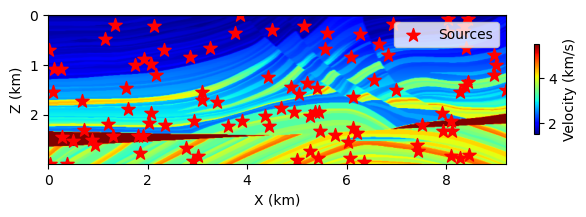

Final shapes:
T0_data_all: (100, 240, 737)
T_data_all: (100, 240, 737)
vel_data_all: (100, 240, 737)
src_data_all: (100, 240, 737)
Tau_data_all: (100, 240, 737)


In [4]:
################################################################
### Data Generation  Pyekfmm: https://github.com/aaspip/pyekfmm/tree/main/pyekfmm
################################################################
# Hyperparameters
n_sources = 100  # Number of sources
nz, nx = 240, 737  # Grid dimensions
dx, dz = 0.0125, 0.0125  # Grid spacing in km

# Initialize data containers
T0_data_all = np.zeros((n_sources, nz, nx), dtype='float32')
T_data_all = np.zeros((n_sources, nz, nx), dtype='float32')
vel_data_all = np.zeros((n_sources, nz, nx), dtype='float32')
src_data_all = np.zeros((n_sources, nz, nx), dtype='float32')

# Load velocity model
try:
    with open('./vel_model/marmousi/marmvz.bin', 'rb') as fd:
        velzz = np.fromfile(fd, dtype=np.float32).reshape([nz, nx], order='F')  # [z, x]
    velz = velzz / 1000  # Convert velocity to km/s
    print(f"Velocity model loaded. Shape: {velz.shape}")
except FileNotFoundError:
    print("Error: Velocity model file not found. Using random data for debugging.")
    velz = np.random.rand(nz, nx) * 3 + 1  # Random velocity between 1 and 4 km/s

# Generate random source points
np.random.seed(202506)  # For reproducibility
source_locs = np.random.randint(0, [nx, nz], size=(n_sources, 2)).astype('float32')  # [x, z]

# Convert to physical coordinates (km)
source_locs_physical = source_locs * [dx, dz]

# Visualization of velocity model with source locations
plt.figure()
plt.imshow(velz, extent=[0, (nx-1)*dx, (nz-1)*dz, 0], cmap='jet')
plt.colorbar(shrink=0.2, label='Velocity (km/s)')
plt.scatter(source_locs_physical[:, 0], source_locs_physical[:, 1], c='red', marker='*', s=100, label='Sources')
plt.xlabel('X (km)')
plt.ylabel('Z (km)')
plt.legend(loc='upper right')
plt.tight_layout()
plt.show()

# Calculate traveltime fields for each source
for src_idx, (sx, sz) in enumerate(source_locs):
    sx, sz = int(sx), int(sz)  # Convert to integer indices
    src_physical = np.array([sz * dz, 0, sx * dx], dtype='float32')  # [x, y, z] in km

    # Populate velocity and source data
    vel_data_all[src_idx] = velz
    src_data_all[src_idx, sz, sx] = 1

    # Heterogeneous velocity computation
    velz_1d = velz.transpose().flatten(order='F')  # [z, x] -> [x, z]
    t = fmm.eikonal(
        velz_1d,
        xyz=src_physical,  # [x, y, z]
        ax=[0, dz, nz],  # x-axis
        ay=[0, dx, 1],   # y-axis (not used in 2D)
        az=[0, dx, nx],  # z-axis
        order=2
    )
    T_data_all[src_idx] = t.reshape(nz, nx, order='F')  # Reshape to [z, x]

    # Homogeneous velocity computation
    vel_homo = velz[sz, sx] * np.ones([nz * nx], dtype='float32')
    t1 = fmm.eikonal(
        vel_homo,
        xyz=src_physical,  # [x, y, z]
        ax=[0, dz, nz],  # x-axis
        ay=[0, dx, 1],   # y-axis (not used in 2D)
        az=[0, dx, nx],  # z-axis
        order=2
    )
    T0_data_all[src_idx] = t1.reshape(nz, nx, order='F')  # Reshape to [z, x]

# Compute Tau data
Tau_data_all = T_data_all - T0_data_all  # Shape: (n_sources, nz, nx)

# Print final shapes
print(f"T0_data_all: {T0_data_all.shape}")
print(f"T_data_all: {T_data_all.shape}")
print(f"vel_data_all: {vel_data_all.shape}")
print(f"src_data_all: {src_data_all.shape}")
print(f"Tau_data_all: {Tau_data_all.shape}")

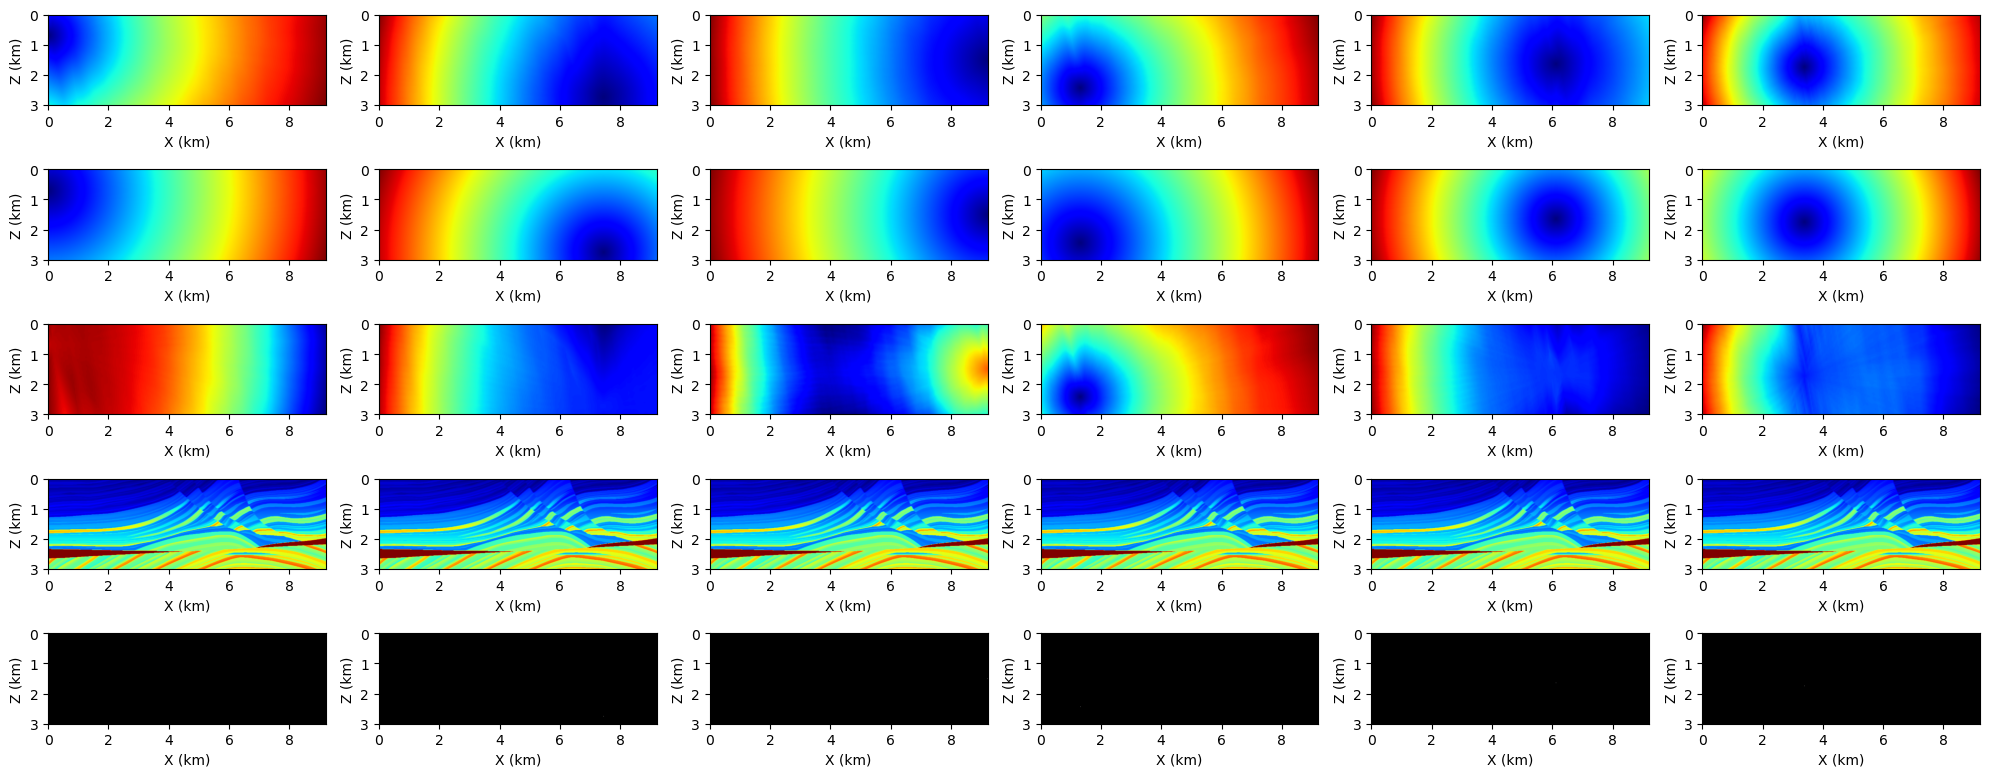

In [5]:
################################################################
### Data Visualization
################################################################
## Visualization of the first 5 results (T, T0, and Tau)
fig, axes = plt.subplots(5, 6, figsize=(20, 8))
for i in range(6):
    # T data
    im0 = axes[0, i].imshow(T_data_all[i], extent=[0, nx*dx, nz*dz, 0], cmap='jet')
    # axes[0, i].set_title(f"T ({source_locs[i][0]*dx:.2f}, {source_locs[i][1]*dz:.2f}) km")
    axes[0, i].set_xlabel('X (km)')
    axes[0, i].set_ylabel('Z (km)')
    # cbar0 = fig.colorbar(im0, ax=axes[0, i], shrink=0.3, pad=0.05)
    # cbar0.set_label('second')

    # T0 data
    im1 = axes[1, i].imshow(T0_data_all[i], extent=[0, nx*dx, nz*dz, 0], cmap='jet')
    # axes[1, i].set_title(f"T0 ({source_locs[i][0]*dx:.2f}, {source_locs[i][1]*dz:.2f}) km")
    axes[1, i].set_xlabel('X (km)')
    axes[1, i].set_ylabel('Z (km)')
    # cbar1 = fig.colorbar(im1, ax=axes[1, i], shrink=0.3, pad=0.05)
    # cbar1.set_label('second')

    # Tau = T - T0
    im2 = axes[2, i].imshow(T_data_all[i] - T0_data_all[i], extent=[0, nx*dx, nz*dz, 0], cmap='jet')
    # axes[2, i].set_title(f"Tau ({source_locs[i][0]*dx:.2f}, {source_locs[i][1]*dz:.2f}) km")
    axes[2, i].set_xlabel('X (km)')
    axes[2, i].set_ylabel('Z (km)')
    # cbar2 = fig.colorbar(im2, ax=axes[2, i], shrink=0.3, pad=0.05)
    # cbar2.set_label('second')

    # Vel model
    im2 = axes[3, i].imshow(vel_data_all[i], extent=[0, nx*dx, nz*dz, 0], cmap='jet')
    # axes[3, i].set_title(f"Vel model")
    axes[3, i].set_xlabel('X (km)')
    axes[3, i].set_ylabel('Z (km)')
    # cbar3 = fig.colorbar(im2, ax=axes[3, i], shrink=0.3, pad=0.05)
    # cbar3.set_label('second')

    # Vel model
    im2 = axes[4, i].imshow(src_data_all[i], extent=[0, nx*dx, nz*dz, 0], cmap='grey')
    # axes[4, i].set_title(f"source location")
    axes[4, i].set_xlabel('X (km)')
    axes[4, i].set_ylabel('Z (km)')
    # cbar4 = fig.colorbar(im2, ax=axes[4, i], shrink=0.3, pad=0.05)
    # cbar4.set_label('second')

plt.tight_layout()
# plt.savefig('test.png', dpi=500)
plt.show()

In [6]:
batch_size = 4
ntrain = 84
nvalid = n_sources - ntrain 

# Convert to tensors
inputs = torch.tensor(T0_data_all.reshape(T0_data_all.shape[0], T0_data_all.shape[1], T0_data_all.shape[2], 1), 
                      dtype=torch.float, requires_grad=True, device=device)
labels = torch.tensor(Tau_data_all, dtype=torch.float, requires_grad=True, device=device)

train_inputs = inputs[:ntrain, :, :, :]
val_inputs = inputs[ntrain:, :, :, :]
train_labels = labels[:ntrain, :, :]
val_labels = labels[ntrain:, :, :]

 
# Create DataLoaders
train_dataset = TensorDataset(train_inputs, train_labels)
valid_dataset = TensorDataset(val_inputs, val_labels)
train_loader = DataLoader(train_dataset, batch_size=batch_size, shuffle=True)
valid_loader = DataLoader(valid_dataset, batch_size=batch_size, shuffle=True)

In [7]:
learning_rate = 2.5e-3
epochs = 2000
modes1, modes2 = 8, 8
width = 8
scheduler_step = epochs//5
scheduler_gamma = 0.5
print(epochs, learning_rate, scheduler_step, scheduler_gamma)


# Model, optimizer, and scheduler
model = KAGFNO2d(modes1=modes1, modes2=modes2, width=width).to(device)
print(f"Model parameters: {count_params(model):,}")
optimizer = optim.Adam(model.parameters(), lr=learning_rate)
# scheduler = optim.lr_scheduler.CosineAnnealingLR(optimizer, T_max=epochs * (ntrain // batch_size))
scheduler = torch.optim.lr_scheduler.StepLR(optimizer, step_size=scheduler_step, gamma=scheduler_gamma)
criterion = nn.MSELoss(reduction='sum')
# criterion = LpLoss(size_average=False)

# Training
start_time = default_timer()
model, losses = train(model, train_loader, valid_loader, epochs, optimizer, scheduler, criterion, device, ntrain, nvalid, batch_size)
# model, losses = train(model, train_loader, epochs, optimizer, scheduler, criterion, device, ntrain, batch_size)
elapsed = default_timer() - start_time
print(f"[Training] Finished. Time: {elapsed:.2f}s ({elapsed / 3600:.2f}h)")

# Save model
save_dir = "./model/Marmousi/KAGFNO/"
os.makedirs(save_dir, exist_ok=True)
save_path = os.path.join(save_dir, f"KAGFNO_marmousi_ep{epochs}_modes{modes1}{modes2}_width{width}_0310.pth")
torch.save(model.state_dict(), save_path)
print(f"Model saved to: {save_path}")
model.eval()

2000 0.0025 400 0.5
Model parameters: 66,209
Epoch 10/2000, Train Loss: 5.647e+03, Val Loss: 5.167e+03, Time: 1.485 s
Epoch 20/2000, Train Loss: 1.586e+03, Val Loss: 1.666e+03, Time: 1.492 s
Epoch 30/2000, Train Loss: 7.634e+02, Val Loss: 6.563e+02, Time: 1.499 s
Epoch 40/2000, Train Loss: 4.220e+02, Val Loss: 4.207e+02, Time: 3.240 s
Epoch 50/2000, Train Loss: 4.252e+02, Val Loss: 8.259e+02, Time: 3.260 s
Epoch 60/2000, Train Loss: 1.321e+03, Val Loss: 4.288e+02, Time: 3.262 s
Epoch 70/2000, Train Loss: 4.943e+02, Val Loss: 5.082e+02, Time: 3.254 s
Epoch 80/2000, Train Loss: 2.034e+02, Val Loss: 2.831e+02, Time: 3.246 s
Epoch 90/2000, Train Loss: 1.900e+02, Val Loss: 2.403e+02, Time: 3.242 s
Epoch 100/2000, Train Loss: 1.733e+02, Val Loss: 1.966e+02, Time: 3.239 s
Epoch 110/2000, Train Loss: 3.485e+03, Val Loss: 3.593e+03, Time: 3.239 s
Epoch 120/2000, Train Loss: 6.405e+02, Val Loss: 5.651e+02, Time: 3.246 s
Epoch 130/2000, Train Loss: 3.951e+02, Val Loss: 7.533e+02, Time: 3.251 s
Ep

KAGFNO2d(
  (p): Linear(in_features=3, out_features=8, bias=True)
  (conv0): SpectralConv2d(
    (mlp4): MLP(
      (mlp1): Conv2d(8, 8, kernel_size=(1, 1), stride=(1, 1))
      (mlp2): Conv2d(8, 8, kernel_size=(1, 1), stride=(1, 1))
    )
    (unet4): U_net(
      (conv1): Sequential(
        (0): Conv2d(8, 8, kernel_size=(1, 1), stride=(2, 2), bias=False)
        (1): BatchNorm2d(8, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
        (2): LeakyReLU(negative_slope=0.1, inplace=True)
        (3): Dropout(p=0, inplace=False)
      )
      (conv2): Sequential(
        (0): Conv2d(8, 8, kernel_size=(1, 1), stride=(2, 2), bias=False)
        (1): BatchNorm2d(8, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
        (2): LeakyReLU(negative_slope=0.1, inplace=True)
        (3): Dropout(p=0, inplace=False)
      )
      (conv2_1): Sequential(
        (0): Conv2d(8, 8, kernel_size=(1, 1), stride=(1, 1), bias=False)
        (1): BatchNorm2d(8, eps=1e-05, mom

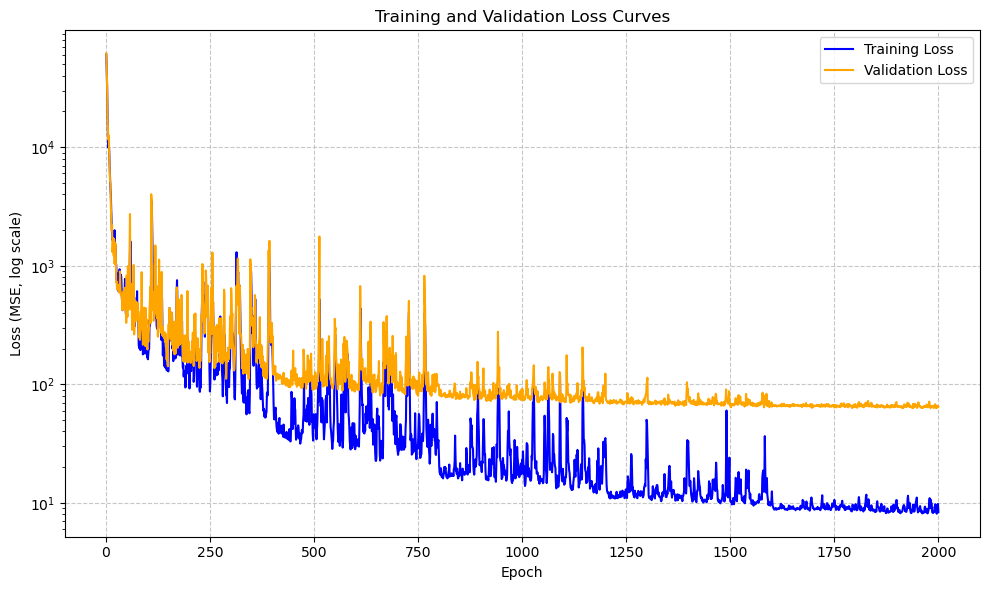

In [8]:
# Loss curve visualization
plt.figure(figsize=(10, 6))
plt.plot(range(1, epochs + 1), losses['train'], label='Training Loss', color='blue')
plt.plot(range(1, epochs + 1), losses['valid'], label='Validation Loss', color='orange')
plt.xlabel('Epoch')
# plt.ylabel('Loss (MSE)')
plt.title('Training and Validation Loss Curves')
plt.legend()
plt.grid(True, linestyle='--', alpha=0.7)

# Optional: Log scale if losses vary widely
plt.yscale('log')
plt.ylabel('Loss (MSE, log scale)')

plt.tight_layout()
plt.show()